# FedResonance — when is each compression mode applied?

This notebook makes the **per-layer, per-round mode-switch rule** of
`algorithms/fed_resonance.py` *visible*: for ResNet-8 (and other models) it shows
each layer's type, matrix shape, and the compression mode FedResonance would use,
plus the SVD rank-selection that decides *how much* a layer is compressed.

**The real switch rule** (exact branch order from `client_update`):

1. `layer_type == "embedding"` → **SPARSE** (Top-k, keep `embedding_topk_ratio`)
2. `layer_type in {"norm","bias"}` → **DENSE** (full, no SVD)
3. else (conv / linear / other):
   - `numel < rank_min*2` → **DENSE**
   - `beta < 0.1` (battery critical) → **SVD_FORCED** (rank = `rank_min`)
   - else, if a stored basis explains the gradient (`proj_energy ≥ rank_coherence_thresh`) → **SUBSPACE** (send only r coefficients)
   - else → **SVD** (adaptive rank; also (re)builds the basis)

`layer_type` is decided by `_detect_layer_type` (name keywords + shape).
Error feedback carries whatever a mode drops, so no gradient info is lost.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # repo root (notebook lives in notebooks/)

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from models.registry import get_model
from algorithms.fed_resonance import (
    _detect_layer_type, _matrix_form, compress_low_rank, FedResonance,
)

# Default config keys FedResonance reads (from get_default_config()).
CFG = FedResonance().get_default_config()
RANK_MIN  = CFG["rank_min"]            # 4
RANK_MAX  = CFG["rank_max"]            # 32
EPS       = CFG["spectral_energy_thresh"]  # 0.95
TAU_RANK  = CFG["rank_coherence_thresh"]   # 0.7  (subspace gate)
print(f"rank_min={RANK_MIN}  rank_max={RANK_MAX}  spectral_energy_thresh={EPS}  rank_coherence_thresh={TAU_RANK}")


rank_min=4  rank_max=32  spectral_energy_thresh=0.95  rank_coherence_thresh=0.7


In [2]:
def static_mode(name, tensor, has_basis=False, battery_critical=False,
                rank_min=RANK_MIN):
    """Replicates the EXACT branch order of FedResonance.client_update.
    Returns (mode, reason). `has_basis`/`battery_critical` are round-dependent;
    at round 0 there is no basis and (on a charged client) no criticality."""
    lt = _detect_layer_type(name, tensor)
    numel = tensor.numel()
    if lt == "embedding":
        return "sparse", "embedding layer → Top-k"
    if lt in ("norm", "bias"):
        return "dense", f"{lt} layer → dense (SVD overhead not worth it)"
    if numel < rank_min * 2:
        return "dense", f"numel {numel} < rank_min*2 ({rank_min*2}) → dense"
    if battery_critical:
        return "svd_forced", "beta<0.1 → SVD at rank_min (max compression)"
    if has_basis:
        return "subspace?", "stored basis: SUBSPACE if proj_energy≥0.7 else SVD"
    return "svd", "no basis yet → SVD (adaptive rank, builds basis)"


In [3]:
def layer_table(model_name, dataset="cifar10"):
    m = get_model(model_name, dataset)
    rows = []
    for name, p in m.named_parameters():
        t = p.detach()
        G = _matrix_form(t)
        mode, reason = static_mode(name, t)
        rows.append(dict(
            layer=name, type=_detect_layer_type(name, t),
            shape=str(tuple(t.shape)), matrix=f"{G.shape[0]}x{G.shape[1]}",
            numel=t.numel(), mode_round0=mode, reason=reason,
        ))
    return pd.DataFrame(rows)

df8 = layer_table("resnet8")
print("ResNet-8 — round-0 modes (no basis yet):")
df8

ResNet-8 — round-0 modes (no basis yet):


,layer,type,shape,matrix,numel,mode_round0,reason
0,stem.0.weight,conv,"(16, 3, 3, 3)",16x27,432,svd,"no basis yet → SVD (adaptive rank, builds basis)"
1,stem.1.weight,norm,"(16,)",16x1,16,dense,norm layer → dense (SVD overhead not worth it)
2,stem.1.bias,bias,"(16,)",16x1,16,dense,bias layer → dense (SVD overhead not worth it)
3,layer1.conv1.weight,conv,"(16, 16, 3, 3)",16x144,2304,svd,"no basis yet → SVD (adaptive rank, builds basis)"
4,layer1.bn1.weight,norm,"(16,)",16x1,16,dense,norm layer → dense (SVD overhead not worth it)
5,layer1.bn1.bias,norm,"(16,)",16x1,16,dense,norm layer → dense (SVD overhead not worth it)
6,layer1.conv2.weight,conv,"(16, 16, 3, 3)",16x144,2304,svd,"no basis yet → SVD (adaptive rank, builds basis)"
7,layer1.bn2.weight,norm,"(16,)",16x1,16,dense,norm layer → dense (SVD overhead not worth it)
8,layer1.bn2.bias,norm,"(16,)",16x1,16,dense,norm layer → dense (SVD overhead not worth it)
9,layer2.conv1.weight,conv,"(32, 16, 3, 3)",32x144,4608,svd,"no basis yet → SVD (adaptive rank, builds basis)"


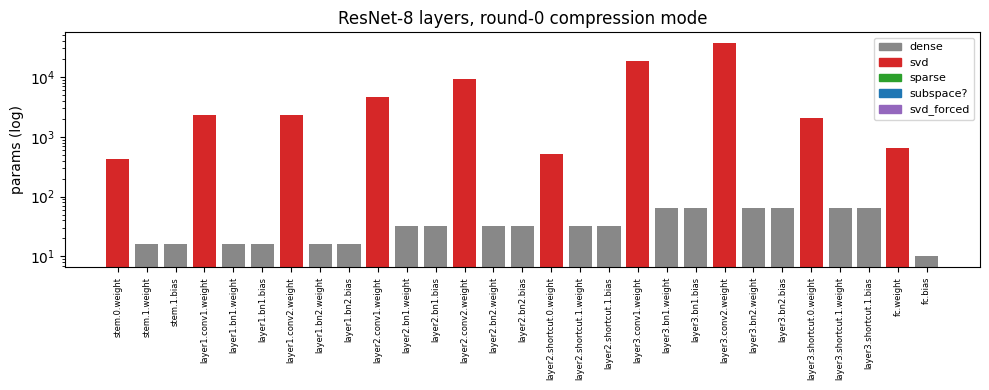

mode_round0
dense    19
svd      10
Name: count, dtype: int64


In [4]:
# How the fleet's per-round modes are distributed (round 0) — by param count.
COLORS = {"dense":"#888888","svd":"#d62728","sparse":"#2ca02c",
          "subspace?":"#1f77b4","svd_forced":"#9467bd"}
fig, ax = plt.subplots(figsize=(10,4))
xs = range(len(df8))
ax.bar(xs, df8["numel"], color=[COLORS[m] for m in df8["mode_round0"]])
ax.set_yscale("log"); ax.set_ylabel("params (log)"); ax.set_title("ResNet-8 layers, round-0 compression mode")
ax.set_xticks(list(xs)); ax.set_xticklabels(df8["layer"], rotation=90, fontsize=6)
handles = [plt.Rectangle((0,0),1,1,color=c) for c in COLORS.values()]
ax.legend(handles, COLORS.keys(), fontsize=8)
plt.tight_layout(); plt.show()

print(df8["mode_round0"].value_counts())

**Read-out (ResNet-8, round 0).** Conv/linear weights → **SVD** (no basis exists
yet, so FedResonance runs SVD and *builds* the basis). BN/bias vectors → **DENSE**
(too small to be worth an SVD). Nothing is an embedding here, so no **SPARSE**.
**SUBSPACE** only appears from round ~2+ once a stored basis explains the new
gradient well enough (`proj_energy ≥ rank_coherence_thresh`) — that is the dynamic
part, demonstrated below.


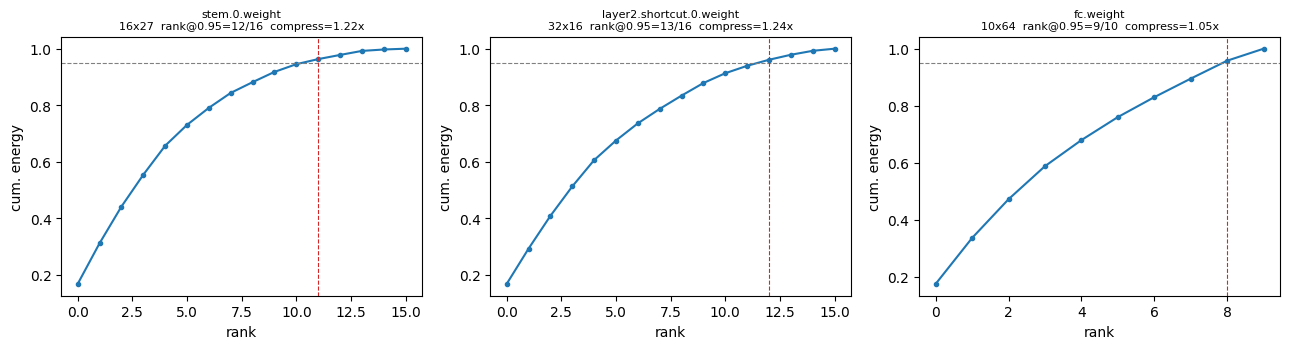

In [5]:
# HOW MUCH is a layer compressed? The adaptive rank picks the smallest r whose
# top-r singular values capture >= spectral_energy_thresh of the energy.
# We use the layer WEIGHT as a stand-in matrix to show the mechanism (real
# gradients are typically MORE low-rank, so compression in training is stronger).
m = get_model("resnet8", "cifar10")
mats = [(n, _matrix_form(p.detach())) for n, p in m.named_parameters() if p.dim() >= 2]
pick = [mats[0], mats[len(mats)//2], mats[-1]]   # shallow, mid, head

fig, axes = plt.subplots(1, len(pick), figsize=(13,3.6))
for ax, (name, G) in zip(axes, pick):
    S = torch.linalg.svdvals(G.float())
    energy = (S**2)
    cum = torch.cumsum(energy, 0) / energy.sum()
    r = int((cum >= EPS).nonzero()[0]) + 1 if (cum >= EPS).any() else len(S)
    r = max(RANK_MIN, min(RANK_MAX, r))
    m_, n_ = G.shape
    cr = (r*(m_+n_+1)) / (m_*n_)         # SVD bytes / dense bytes
    ax.plot(cum.numpy(), marker=".")
    ax.axhline(EPS, color="grey", ls="--", lw=0.8)
    ax.axvline(r-1, color="#d62728", ls="--", lw=0.8)
    ax.set_title(f"{name}\n{m_}x{n_}  rank@{EPS}={r}/{min(m_,n_)}  compress={cr:.2f}x", fontsize=8)
    ax.set_xlabel("rank"); ax.set_ylabel("cum. energy")
plt.tight_layout(); plt.show()

**Compression ratio** = SVD bytes `r·(m+n+1)` / dense bytes `m·n`. A value < 1
means the SVD transmission is cheaper than sending the dense layer; > 1 means SVD
is *not* worth it (tiny / near-full-rank layers) — which is exactly why
FedResonance keeps small layers **dense**. On freshly-initialised weights the
spectrum is near-flat (little compression); real training gradients decay faster,
so the chosen rank — and the savings — are larger in practice.


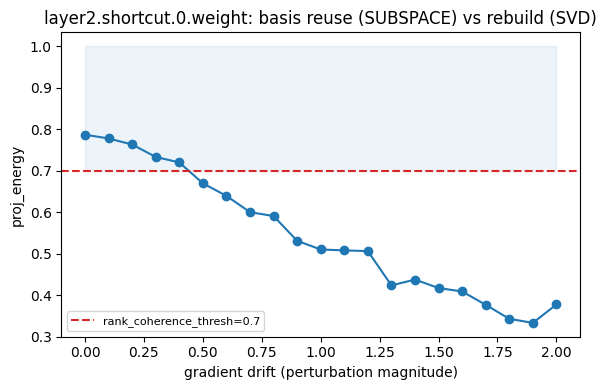

Above the line → SUBSPACE (reuse basis, send r coeffs); below → SVD (rebuild).


In [6]:
# DYNAMIC: subspace vs SVD. Build a basis B (rank r) from a layer's SVD, then
# perturb the gradient and watch proj_energy = ||B B^T G'||^2 / ||G'||^2.
# proj_energy >= rank_coherence_thresh (0.7) -> SUBSPACE (cheap); else -> SVD.
name, G0 = mats[len(mats)//2]
G0 = G0.float()
U, S, Vt = torch.linalg.svd(G0, full_matrices=False)
r = max(RANK_MIN, min(RANK_MAX, 8))
B = U[:, :r]                                    # stored basis (m x r)

eps_grid = np.linspace(0, 2.0, 21)
proj = []
torch.manual_seed(0)
for e in eps_grid:
    noise = torch.randn_like(G0); noise = noise / noise.norm() * G0.norm()
    Gp = G0 + e * noise
    pe = ((B @ (B.t() @ Gp)).pow(2).sum() / Gp.pow(2).sum()).item()
    proj.append(pe)

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(eps_grid, proj, "o-")
ax.axhline(TAU_RANK, color="#d62728", ls="--", label=f"rank_coherence_thresh={TAU_RANK}")
ax.fill_between(eps_grid, TAU_RANK, 1.0, alpha=0.08, color="#1f77b4")
ax.set_xlabel("gradient drift (perturbation magnitude)"); ax.set_ylabel("proj_energy")
ax.set_title(f"{name}: basis reuse (SUBSPACE) vs rebuild (SVD)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print("Above the line → SUBSPACE (reuse basis, send r coeffs); below → SVD (rebuild).")

## The four parameters explanation

| param | role (in the real code) | ↑ raises it ⇒ | speed / energy | convergence |
|---|---|---|---|---|
| **`rank_coherence_thresh`** (`tau_rank`, 0.7) | min `proj_energy` for **SUBSPACE** vs SVD (line ~1074) | stricter → more **SVD** | more comm+compute, more accurate gradient | slightly faster per useful round; lower → more subspace reuse (cheaper, EF covers staleness) |
| **`rsvd_oversample`** (`p`, 10) | extra random columns for randomized SVD accuracy | more accurate rSVD | a bit slower / more memory | negligible |
| **`rsvd_power_iter`** (`q`, 2) | power iterations for rSVD on slow-decaying spectra | more accurate rSVD | slower | negligible |
| **`subspace_drift_thresh`** (`tau_drift`, 0.1) | *intended* basis-staleness gate | — | — | — |

**Honesty note (read from the code):** `subspace_drift_thresh` is currently
**read but not used** — `subspace_drift()` is never called in `client_update`; the
basis-staleness decision is made entirely by `proj_energy ≥ rank_coherence_thresh`.
So changing `subspace_drift_thresh` has **no effect** today. The docstring still
lists it as part of the rule; the code does not implement that gate.

**With `svd_fast=True` (default):** ResNet-8 layers are small (`min(m,n) ≤ 256`),
so they take the **full-SVD** path — `rsvd_oversample`/`rsvd_power_iter` then only
matter for *large* matrices (the randomized path). They do **not** change which
mode is chosen, only the SVD numerics.


/Users/joshuajusteyunpeinikiema/Documents/PhD_UM6P/Stat_of_art_EnergyEfficientFL/fedlab_zmq/models/registry.py:305: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)


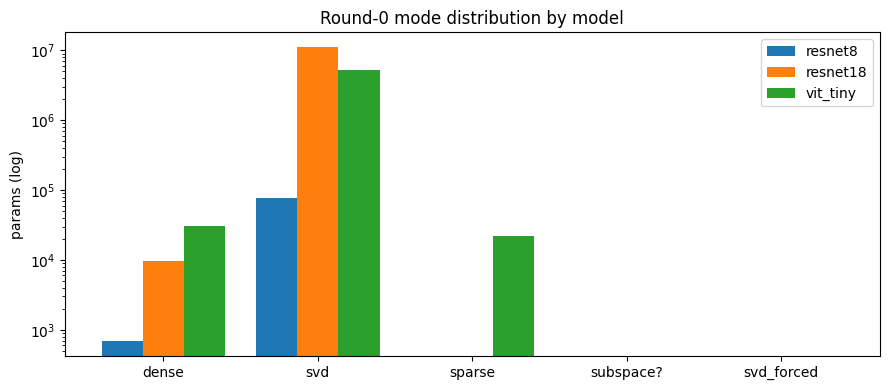

In [7]:
# Mode distribution across architectures (round 0), by parameter count.
fig, ax = plt.subplots(figsize=(9,4))
models = ["resnet8", "resnet18", "vit_tiny"]
allmodes = ["dense","svd","sparse","subspace?","svd_forced"]
width = 0.8/len(models)
for i, mn in enumerate(models):
    try:
        d = layer_table(mn)
    except Exception as ex:
        print(f"skip {mn}: {ex}"); continue
    by = d.groupby("mode_round0")["numel"].sum()
    vals = [by.get(mm, 0) for mm in allmodes]
    ax.bar([x + i*width for x in range(len(allmodes))], vals, width, label=mn)
ax.set_yscale("log"); ax.set_ylabel("params (log)")
ax.set_xticks([x + width for x in range(len(allmodes))]); ax.set_xticklabels(allmodes)
ax.set_title("Round-0 mode distribution by model"); ax.legend()
plt.tight_layout(); plt.show()

## Dynamic run — the mode each layer uses, every round (10 clients × 50 rounds)

The cells above are *static* (round-0 rule). The cell below runs a **real
FedResonance training** and records, for **4 sampled clients**, the actual
`mode_per_layer` from `client_update` at **each of 50 rounds**, then draws one
heatmap per client (rows = layers that ever compress, columns = rounds, colour =
mode). You should see the expected lifecycle:

- **rounds 0–1** → all **dense** (warm-up, `warmup_rounds=2` = plain FedAvg);
- **round 2** → conv/linear layers switch to **SVD** (no basis yet → build one);
- **rounds 3+** → many layers flip to **SUBSPACE** (the stored basis still explains
  the gradient: `proj_energy ≥ rank_coherence_thresh`), with occasional **SVD**
  refreshes when a basis goes stale.

Norm/bias/tiny layers stay **dense** throughout (filtered out of the heatmap for
clarity; see the text summary at the bottom for full per-round counts).


> **⚠️ Pitfall — `quant_bits` vs `error_budget` (energy-aware mode).** With
> `energy_aware_selection: true`, a mode is only a candidate if its relative
> reconstruction error ≤ `error_budget`. **1-bit quant (signSGD)** has error
> ~0.2–0.4, so with `error_budget=0.10` it is *rejected* — and so are sparse/SVD
> on noisy gradients. The only feasible mode left is **dense** → the upload becomes
> the **full model** (comm ×4 vs compressed FedResonance). This is *not* a bug: on
> RPi4 `e_per_byte/e_per_flop ≈ 200`, so the selector always prefers a compressing
> mode *when one is feasible*. Fix: use `quant_bits=8` (err ~0.008, comm ×0.25) or
> `quant_bits=4` with `error_budget=0.20` (comm ×0.13). **Never pair 1-bit signSGD
> with a tight error budget.**


done: 50 rounds × 10 clients on mps (energy-aware selection)


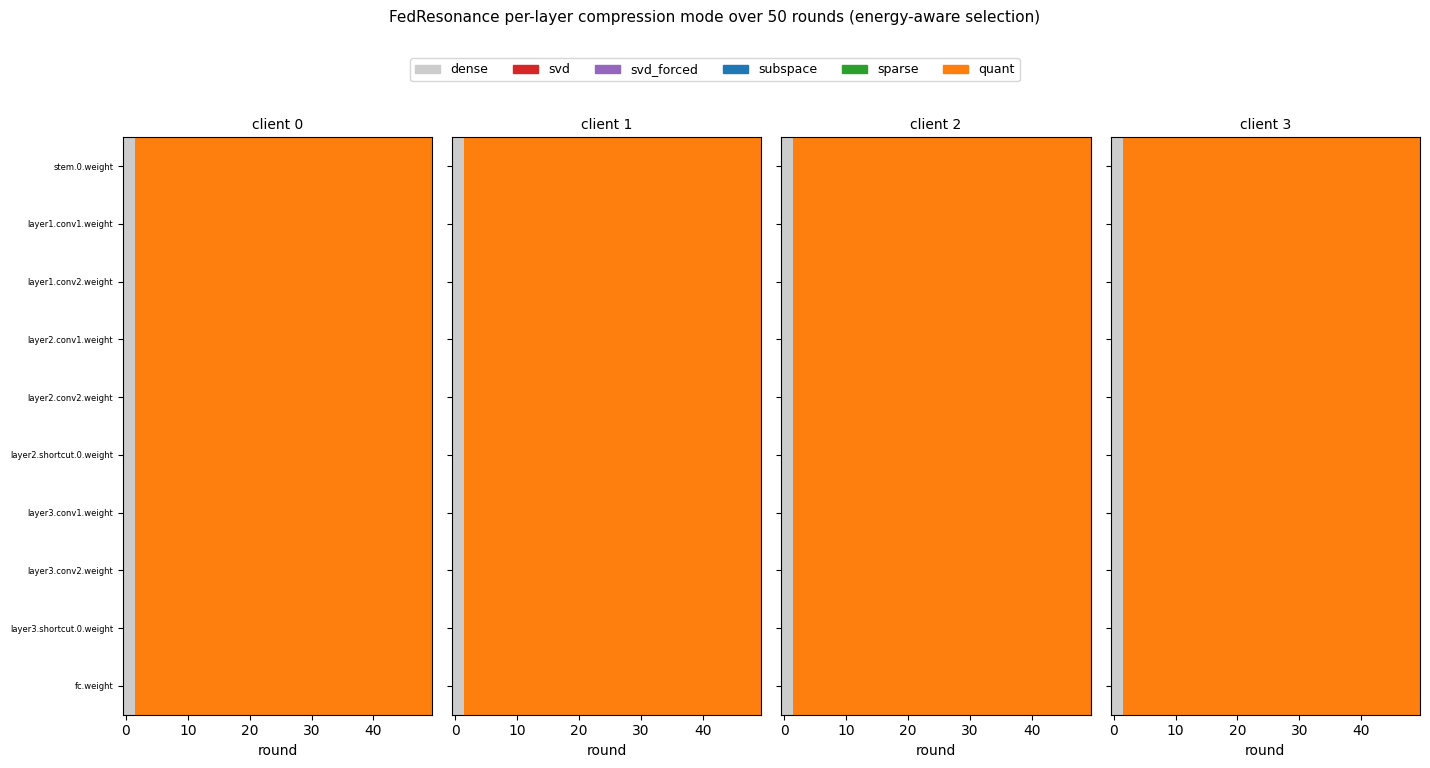


client 0 — mode counts per round:
  round  0: {'dense': 56}
  round  5: {'quant': 10, 'dense': 46}
  round 10: {'quant': 10, 'dense': 46}
  round 15: {'quant': 10, 'dense': 46}
  round 20: {'quant': 10, 'dense': 46}
  round 25: {'quant': 10, 'dense': 46}
  round 30: {'quant': 10, 'dense': 46}
  round 35: {'quant': 10, 'dense': 46}
  round 40: {'quant': 10, 'dense': 46}
  round 45: {'quant': 10, 'dense': 46}


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# DYNAMIC RUN: per-round, per-layer compression mode over a REAL FedResonance
# training (10 clients × 50 rounds). For 4 sampled clients we record the actual
# `mode_per_layer` returned by FedResonance.client_update each round, then draw a
# heatmap. A small per-client data subset keeps the notebook fast — the *modes*
# (not the accuracy) are the point. Expect a few minutes on CPU/MPS.
#
# Toggle ENERGY_AWARE:
#   False -> structural rule (warmup→SVD→SUBSPACE lifecycle, this notebook's story)
#   True  -> NEW energy-aware selection: per layer argmin(compute+comm energy)
#            s.t. rel-error ≤ error_budget; the cheap `quant` mode wins because
#            SVD compute (~190× more FLOPs) is no longer treated as free.
# ─────────────────────────────────────────────────────────────────────────────
import torch
from torch.utils.data import DataLoader, Subset
from matplotlib.colors import ListedColormap
from datasets.registry import get_dataloader
from algorithms.base import ClientState

torch.manual_seed(0)
NUM_CLIENTS, ROUNDS, SHOWN = 10, 50, [0, 1, 2, 3]
DATASET, MODELN = "cifar10", "resnet8"
DEV = "mps" if torch.backends.mps.is_available() else "cpu"
SUBSET = 256          # samples per client (notebook speed; raise for realism)
ENERGY_AWARE = True   # energy-aware selection ON (quant wins; needs quant_bits>=4 vs error_budget!)

def make_loader(cid):
    dl = get_dataloader(DATASET, "train", "dirichlet", client_id=cid,
                        num_clients=NUM_CLIENTS, alpha=0.5, batch_size=64, seed=42)
    n = min(SUBSET, len(dl.dataset))
    return DataLoader(Subset(dl.dataset, list(range(n))), batch_size=64, shuffle=True)

loaders = {c: make_loader(c) for c in range(NUM_CLIENTS)}

algo = FedResonance()
cfg = dict(CFG)
cfg.update(dict(lr=0.01, local_epochs=1, optimizer="sgd", momentum=0.9,
                weight_decay=1e-4, warmup_rounds=2,
                battery_max_j=200_000.0, energy_scale_factor=3.0,
                use_error_feedback=True, svd_fast=True,
                energy_aware_selection=ENERGY_AWARE, error_budget=0.15, quant_bits=8, device=DEV))

gmodel = get_model(MODELN, DATASET).to(DEV)
cmodel = get_model(MODELN, DATASET).to(DEV)        # reused client model
states = {c: ClientState(client_id=c, battery_j=cfg["battery_max_j"])
          for c in range(NUM_CLIENTS)}

record = {c: [] for c in SHOWN}                    # client -> [mode_per_layer per round]
for r in range(ROUNDS):
    gsd = gmodel.state_dict()
    cups = []
    for c in range(NUM_CLIENTS):
        cmodel.load_state_dict(gsd)                # client starts from global weights
        upd, meta = algo.client_update(cmodel, loaders[c], states[c], cfg)
        cups.append((upd, meta, states[c]))
        if c in SHOWN:
            record[c].append(meta["mode_per_layer"])
    res = algo.server_aggregate(gmodel, cups, r, cfg)
    gmodel.load_state_dict(res.new_weights)
regime = "energy-aware" if ENERGY_AWARE else "structural"
print(f"done: {ROUNDS} rounds × {NUM_CLIENTS} clients on {DEV} ({regime} selection)")

# ── Heatmap: layers (that ever compress) × rounds, coloured by mode, per client ──
MODES = ["dense", "svd", "svd_forced", "subspace", "sparse", "quant"]
MCOL  = {"dense":"#cccccc","svd":"#d62728","svd_forced":"#9467bd",
         "subspace":"#1f77b4","sparse":"#2ca02c","quant":"#ff7f0e"}
midx  = {m: i for i, m in enumerate(MODES)}
cmap  = ListedColormap([MCOL[m] for m in MODES])

all_layers = list(record[SHOWN[0]][0].keys())
# keep only layers that are NOT always-dense (the ones with interesting dynamics)
dynamic = [l for l in all_layers
           if any(record[SHOWN[0]][r].get(l) != "dense" for r in range(ROUNDS))]

fig, axes = plt.subplots(1, len(SHOWN), figsize=(3.6*len(SHOWN), 7), sharey=True)
for ax, c in zip(axes, SHOWN):
    M = np.array([[midx.get(record[c][r].get(l, "dense"), 0) for r in range(ROUNDS)]
                  for l in dynamic])
    ax.imshow(M, aspect="auto", cmap=cmap, vmin=0, vmax=len(MODES)-1,
              interpolation="nearest")
    ax.set_title(f"client {c}", fontsize=10); ax.set_xlabel("round")
axes[0].set_yticks(range(len(dynamic)))
axes[0].set_yticklabels(dynamic, fontsize=6)
handles = [plt.Rectangle((0, 0), 1, 1, color=MCOL[m]) for m in MODES]
fig.legend(handles, MODES, ncol=len(MODES), loc="upper center",
           bbox_to_anchor=(0.5, 1.03), fontsize=9)
fig.suptitle(f"FedResonance per-layer compression mode over {ROUNDS} rounds "
             f"({regime} selection)", y=1.09, fontsize=11)
plt.tight_layout(); plt.show()

# Compact per-round mode counts for client 0 (text summary)
from collections import Counter
print("\nclient 0 — mode counts per round:")
for r in range(0, ROUNDS, max(1, ROUNDS // 10)):
    print(f"  round {r:>2}: {dict(Counter(record[0][r].values()))}")

## Comparison run — `ENERGY_AWARE = False` (structural rule)

Same training, but with the **structural** selection (the flag OFF). Here the
mode is chosen by layer *type* + battery, not by an energy budget, so you see the
full **dense → SVD → SUBSPACE** lifecycle. Compare the heatmap below with the
energy-aware one above:

| | `ENERGY_AWARE=False` (structural) | `ENERGY_AWARE=True` (cost-accounting) |
|---|---|---|
| conv/linear modes | **SVD** (build basis) → **SUBSPACE** (reuse) | **QUANT** only |
| SVD used? | yes | **no** — its decomposition FLOPs (6·m·n·min) dominate energy → loses to quant |
| SUBSPACE used? | yes | **no** — a basis is only stored when SVD is *selected*; SVD never is → no basis ever exists |
| 1-D / BN / bias | dense | dense |

**So with `ENERGY_AWARE=True` on the RPi4 fleet, SVD/subspace are deselected** —
that *is* the cost-accounting ablation. ⚠️ It is **hardware-dependent**, not
absolute: on a compute-cheap device (e.g. Jetson Nano, 472 GFLOPS,
`e_byte/e_flop≈1573`) SVD compute becomes negligible and **SVD reappears** as the
min-energy mode for the larger layers.

done: 50 rounds × 10 clients on mps (structural selection)


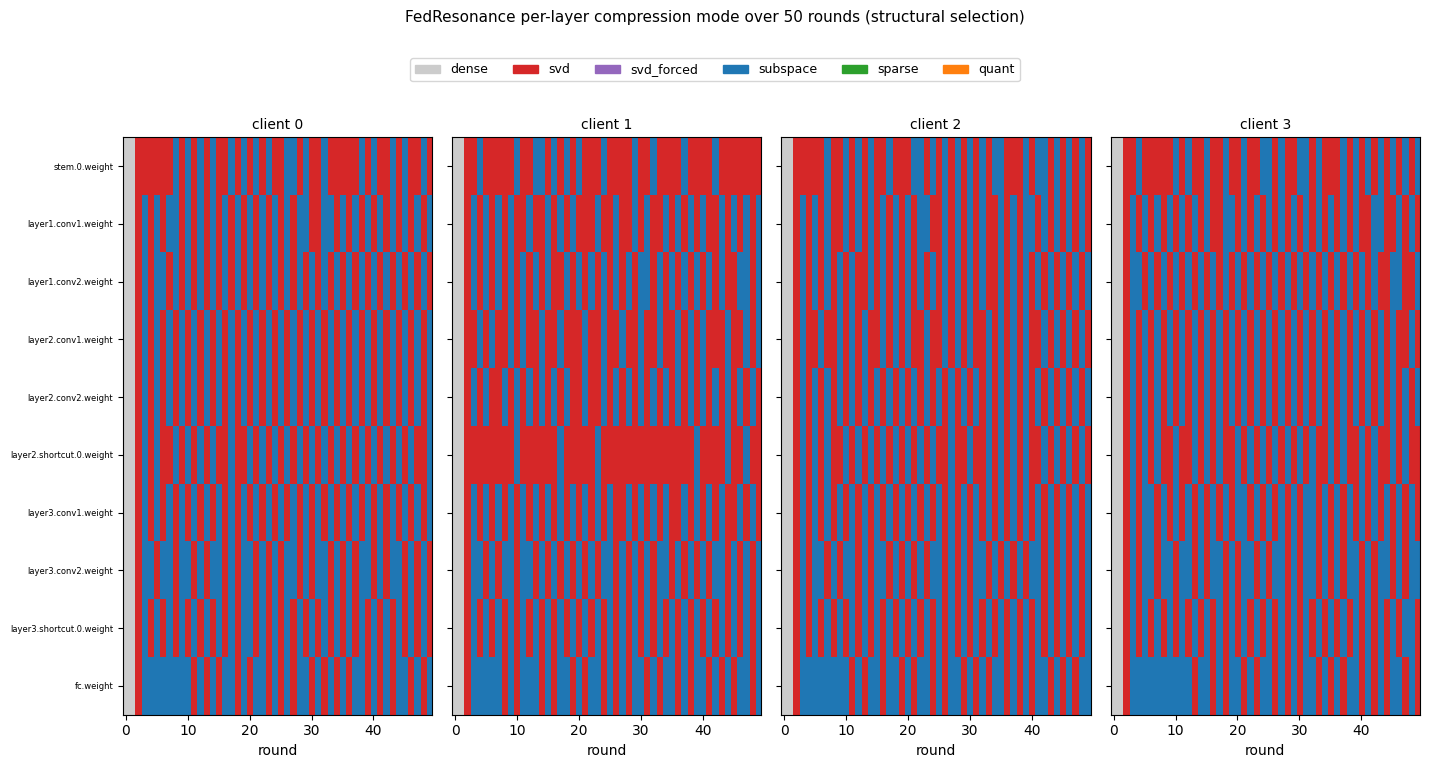


client 0 — mode counts per round:
  round  0: {'dense': 56}
  round  5: {'svd': 2, 'dense': 46, 'subspace': 8}
  round 10: {'subspace': 6, 'dense': 46, 'svd': 4}
  round 15: {'svd': 5, 'dense': 46, 'subspace': 5}
  round 20: {'svd': 5, 'dense': 46, 'subspace': 5}
  round 25: {'svd': 7, 'dense': 46, 'subspace': 3}
  round 30: {'svd': 7, 'dense': 46, 'subspace': 3}
  round 35: {'svd': 5, 'dense': 46, 'subspace': 5}
  round 40: {'subspace': 5, 'dense': 46, 'svd': 5}
  round 45: {'subspace': 6, 'dense': 46, 'svd': 4}


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# DYNAMIC RUN: per-round, per-layer compression mode over a REAL FedResonance
# training (10 clients × 50 rounds). For 4 sampled clients we record the actual
# `mode_per_layer` returned by FedResonance.client_update each round, then draw a
# heatmap. A small per-client data subset keeps the notebook fast — the *modes*
# (not the accuracy) are the point. Expect a few minutes on CPU/MPS.
#
# Toggle ENERGY_AWARE:
#   False -> structural rule (warmup→SVD→SUBSPACE lifecycle, this notebook's story)
#   True  -> NEW energy-aware selection: per layer argmin(compute+comm energy)
#            s.t. rel-error ≤ error_budget; the cheap `quant` mode wins because
#            SVD compute (~190× more FLOPs) is no longer treated as free.
# ─────────────────────────────────────────────────────────────────────────────
import torch
from torch.utils.data import DataLoader, Subset
from matplotlib.colors import ListedColormap
from datasets.registry import get_dataloader
from algorithms.base import ClientState

torch.manual_seed(0)
NUM_CLIENTS, ROUNDS, SHOWN = 10, 50, [0, 1, 2, 3]
DATASET, MODELN = "cifar10", "resnet8"
DEV = "mps" if torch.backends.mps.is_available() else "cpu"
SUBSET = 256          # samples per client (notebook speed; raise for realism)
ENERGY_AWARE = False  # structural rule: warmup -> SVD (builds basis) -> SUBSPACE reuse

def make_loader(cid):
    dl = get_dataloader(DATASET, "train", "dirichlet", client_id=cid,
                        num_clients=NUM_CLIENTS, alpha=0.5, batch_size=64, seed=42)
    n = min(SUBSET, len(dl.dataset))
    return DataLoader(Subset(dl.dataset, list(range(n))), batch_size=64, shuffle=True)

loaders = {c: make_loader(c) for c in range(NUM_CLIENTS)}

algo = FedResonance()
cfg = dict(CFG)
cfg.update(dict(lr=0.01, local_epochs=1, optimizer="sgd", momentum=0.9,
                weight_decay=1e-4, warmup_rounds=2,
                battery_max_j=200_000.0, energy_scale_factor=3.0,
                use_error_feedback=True, svd_fast=True,
                energy_aware_selection=ENERGY_AWARE, error_budget=0.15, quant_bits=8, device=DEV))

gmodel = get_model(MODELN, DATASET).to(DEV)
cmodel = get_model(MODELN, DATASET).to(DEV)        # reused client model
states = {c: ClientState(client_id=c, battery_j=cfg["battery_max_j"])
          for c in range(NUM_CLIENTS)}

record = {c: [] for c in SHOWN}                    # client -> [mode_per_layer per round]
for r in range(ROUNDS):
    gsd = gmodel.state_dict()
    cups = []
    for c in range(NUM_CLIENTS):
        cmodel.load_state_dict(gsd)                # client starts from global weights
        upd, meta = algo.client_update(cmodel, loaders[c], states[c], cfg)
        cups.append((upd, meta, states[c]))
        if c in SHOWN:
            record[c].append(meta["mode_per_layer"])
    res = algo.server_aggregate(gmodel, cups, r, cfg)
    gmodel.load_state_dict(res.new_weights)
regime = "energy-aware" if ENERGY_AWARE else "structural"
print(f"done: {ROUNDS} rounds × {NUM_CLIENTS} clients on {DEV} ({regime} selection)")

# ── Heatmap: layers (that ever compress) × rounds, coloured by mode, per client ──
MODES = ["dense", "svd", "svd_forced", "subspace", "sparse", "quant"]
MCOL  = {"dense":"#cccccc","svd":"#d62728","svd_forced":"#9467bd",
         "subspace":"#1f77b4","sparse":"#2ca02c","quant":"#ff7f0e"}
midx  = {m: i for i, m in enumerate(MODES)}
cmap  = ListedColormap([MCOL[m] for m in MODES])

all_layers = list(record[SHOWN[0]][0].keys())
# keep only layers that are NOT always-dense (the ones with interesting dynamics)
dynamic = [l for l in all_layers
           if any(record[SHOWN[0]][r].get(l) != "dense" for r in range(ROUNDS))]

fig, axes = plt.subplots(1, len(SHOWN), figsize=(3.6*len(SHOWN), 7), sharey=True)
for ax, c in zip(axes, SHOWN):
    M = np.array([[midx.get(record[c][r].get(l, "dense"), 0) for r in range(ROUNDS)]
                  for l in dynamic])
    ax.imshow(M, aspect="auto", cmap=cmap, vmin=0, vmax=len(MODES)-1,
              interpolation="nearest")
    ax.set_title(f"client {c}", fontsize=10); ax.set_xlabel("round")
axes[0].set_yticks(range(len(dynamic)))
axes[0].set_yticklabels(dynamic, fontsize=6)
handles = [plt.Rectangle((0, 0), 1, 1, color=MCOL[m]) for m in MODES]
fig.legend(handles, MODES, ncol=len(MODES), loc="upper center",
           bbox_to_anchor=(0.5, 1.03), fontsize=9)
fig.suptitle(f"FedResonance per-layer compression mode over {ROUNDS} rounds "
             f"({regime} selection)", y=1.09, fontsize=11)
plt.tight_layout(); plt.show()

# Compact per-round mode counts for client 0 (text summary)
from collections import Counter
print("\nclient 0 — mode counts per round:")
for r in range(0, ROUNDS, max(1, ROUNDS // 10)):
    print(f"  round {r:>2}: {dict(Counter(record[0][r].values()))}")

## Energy-aware on different hardware — Jetson Nano & a mixed fleet

The energy-aware pick is **hardware-dependent**: it minimises
`e_compute + e_comm`, and the balance is set by `e_byte / e_flop` of the device.

| device | peak | `e_byte/e_flop` | consequence |
|---|---|---|---|
| Raspberry Pi 4 | 24 GFLOPS | ≈ 200 | compute matters → cheap `quant` wins; SVD's decomposition FLOPs lose |
| Jetson Nano | 472 GFLOPS | ≈ 1573 | compute almost free → low-rank `svd`/`subspace` (fewest bytes) win on the big layers |

We also enable **`ea_basis_refresh_period`**: every *K* rounds the layer is forced
to upload **SVD** (so the basis is *transmitted* and the server caches it); on the
*K−1* rounds in between, **`subspace`** becomes a decodable candidate that reuses
that synced basis. This is the only correct way to make `subspace` fire — a purely
*local* basis would desync the server's decode (the server only learns a basis from
an SVD upload). We loosen `error_budget` to 0.5 so the reused basis stays feasible
across round-to-round gradient drift.

Below: (1) an all-Jetson fleet, then (2) a mixed Jetson + RPi4 fleet where you can
see **the same algorithm pick different modes per client** purely from hardware.

/Users/joshuajusteyunpeinikiema/Documents/PhD_UM6P/Stat_of_art_EnergyEfficientFL/fedlab_zmq/algorithms/fed_resonance.py:1517: UserWarning: [flop_cost] cost_model='measured': absolute compute FLOPs are ~2 orders of magnitude larger than the analytic 'phi' estimator (3*2*num_params*B*S). The energy_scale_factor (e.g. 12.6) was calibrated against the analytic model and will need a separate recalibration. Relative ordering between algorithms is preserved.
  flops = round_compute_flops(


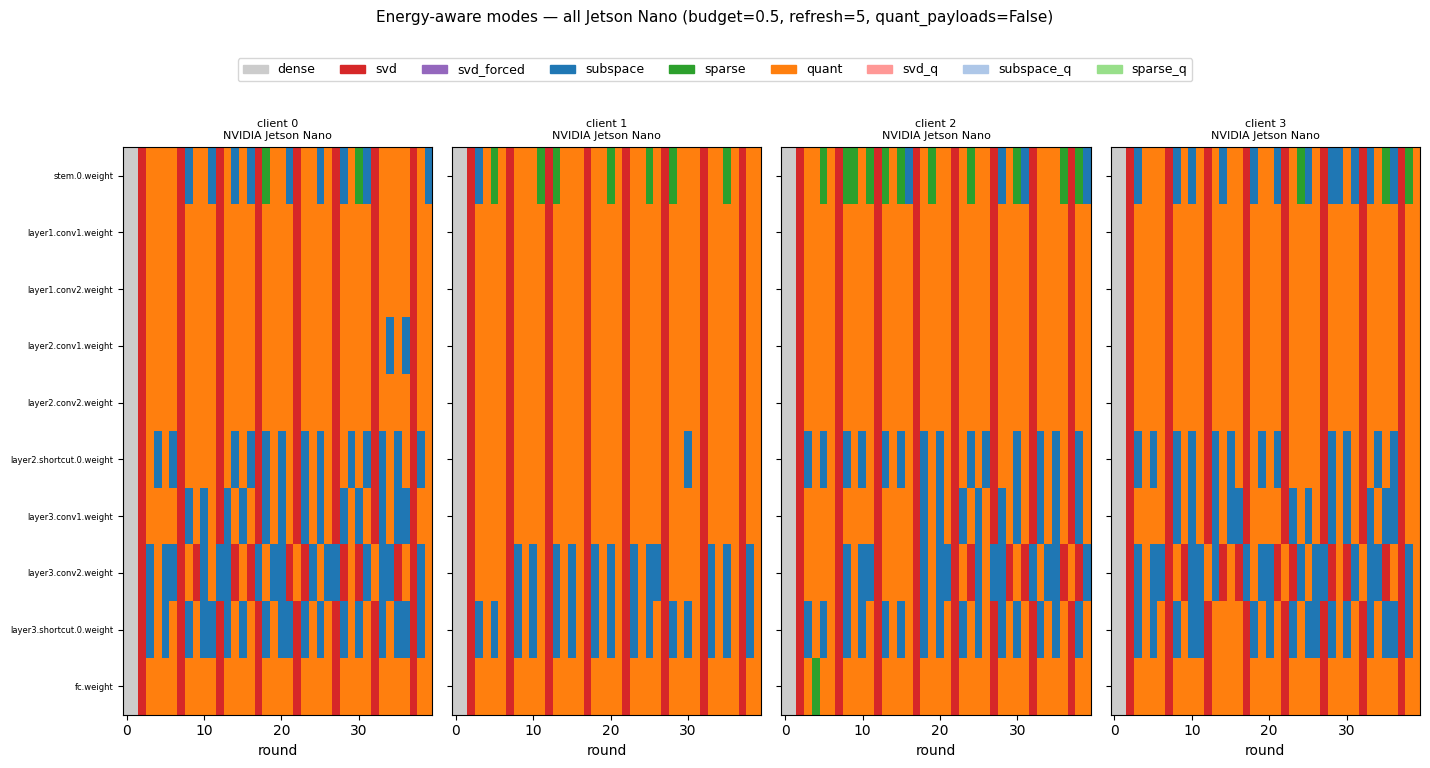

[all Jetson Nano] client 0 (NVIDIA Jetson Nano) — modes per round:
  round  0: {'dense': 56}
  round  4: {'quant': 9, 'dense': 46, 'subspace': 1}
  round  8: {'subspace': 3, 'dense': 46, 'quant': 7}
  round 12: {'svd': 9, 'dense': 46, 'subspace': 1}
  round 16: {'subspace': 2, 'dense': 46, 'quant': 7, 'svd': 1}
  round 20: {'quant': 6, 'dense': 46, 'subspace': 4}
  round 24: {'quant': 9, 'dense': 46, 'subspace': 1}
  round 28: {'subspace': 3, 'dense': 46, 'quant': 6, 'svd': 1}
  round 32: {'svd': 9, 'dense': 46, 'quant': 1}
  round 36: {'quant': 7, 'dense': 46, 'subspace': 3}


In [10]:
# Energy-aware modes across hardware. Reusable runner: profile_of(client_id) sets
# each client's DeviceProfile, so the SAME algorithm sees different energy trade-offs.
from hardware.profiles import DEVICE_PROFILES
from collections import Counter
from matplotlib.colors import ListedColormap

_MODES = ["dense","svd","svd_forced","subspace","sparse","quant",
          "svd_q","subspace_q","sparse_q"]   # *_q = structural mode  quant payload
_MCOL  = {"dense":"#cccccc","svd":"#d62728","svd_forced":"#9467bd",
          "subspace":"#1f77b4","sparse":"#2ca02c","quant":"#ff7f0e",
          "svd_q":"#ff9896","subspace_q":"#aec7e8","sparse_q":"#98df8a"}

def run_energy_aware(profile_of, *, label, num_clients=10, rounds=40, shown=(0,1,2,3),
                     budget=0.5, refresh_period=5, quant_bits=8, subset=256,
                     quantize_payloads=False, payload_bits=8):
    torch.manual_seed(0)
    def mk(c):
        dl = get_dataloader("cifar10","train","dirichlet", client_id=c,
                            num_clients=num_clients, alpha=0.5, batch_size=64, seed=42)
        n = min(subset, len(dl.dataset))
        return DataLoader(Subset(dl.dataset, list(range(n))), batch_size=64, shuffle=True)
    loaders = {c: mk(c) for c in range(num_clients)}
    algo = FedResonance()
    base = dict(algo.get_default_config())
    base.update(dict(lr=0.01, local_epochs=1, optimizer="sgd", momentum=0.9,
                     weight_decay=1e-4, warmup_rounds=2, battery_max_j=200_000.0,
                     energy_scale_factor=3.0, use_error_feedback=True, svd_fast=True,
                     energy_aware_selection=True, error_budget=budget, quant_bits=quant_bits,
                     ea_basis_refresh_period=refresh_period,
                     ea_quantize_payloads=quantize_payloads, ea_payload_bits=payload_bits,
                     device=DEV))
    g  = get_model("resnet8","cifar10").to(DEV)
    cm = get_model("resnet8","cifar10").to(DEV)
    st = {c: ClientState(client_id=c, battery_j=base["battery_max_j"]) for c in range(num_clients)}
    rec = {c: [] for c in shown}
    for r in range(rounds):
        gsd = g.state_dict(); cups = []
        for c in range(num_clients):
            cm.load_state_dict(gsd)
            cfg = dict(base); cfg["device_profile"] = profile_of(c)   # per-client hardware
            upd, meta = algo.client_update(cm, loaders[c], st[c], cfg)
            cups.append((upd, meta, st[c]))
            if c in shown: rec[c].append(meta["mode_per_layer"])
        res = algo.server_aggregate(g, cups, r, cfg); g.load_state_dict(res.new_weights)

    cmap = ListedColormap([_MCOL[m] for m in _MODES]); midx = {m:i for i,m in enumerate(_MODES)}
    layers = list(rec[shown[0]][0].keys())
    dyn = [l for l in layers if any(rec[shown[0]][r].get(l) != "dense" for r in range(rounds))]
    fig, axes = plt.subplots(1, len(shown), figsize=(3.6*len(shown), 7), sharey=True)
    for ax, c in zip(axes, shown):
        M = np.array([[midx.get(rec[c][r].get(l,"dense"),0) for r in range(rounds)] for l in dyn])
        ax.imshow(M, aspect="auto", cmap=cmap, vmin=0, vmax=len(_MODES)-1, interpolation="nearest")
        ax.set_title(f"client {c}\n{profile_of(c).name}", fontsize=8); ax.set_xlabel("round")
    axes[0].set_yticks(range(len(dyn))); axes[0].set_yticklabels(dyn, fontsize=6)
    handles = [plt.Rectangle((0,0),1,1,color=_MCOL[m]) for m in _MODES]
    fig.legend(handles, _MODES, ncol=len(_MODES), loc="upper center",
               bbox_to_anchor=(0.5,1.03), fontsize=9)
    fig.suptitle(f"Energy-aware modes — {label} (budget={budget}, refresh={refresh_period}, "
                 f"quant_payloads={quantize_payloads})",
                 y=1.09, fontsize=11)
    plt.tight_layout(); plt.show()
    print(f"[{label}] client {shown[0]} ({profile_of(shown[0]).name}) — modes per round:")
    for r in range(0, rounds, max(1, rounds//10)):
        print(f"  round {r:>2}: {dict(Counter(rec[shown[0]][r].values()))}")
    return rec

# (1) ALL-JETSON fleet — cheap compute => svd/subspace win on the big layers.
JET = DEVICE_PROFILES["jetson_nano"]
_ = run_energy_aware(lambda c: JET, label="all Jetson Nano", refresh_period=5, budget=0.5)

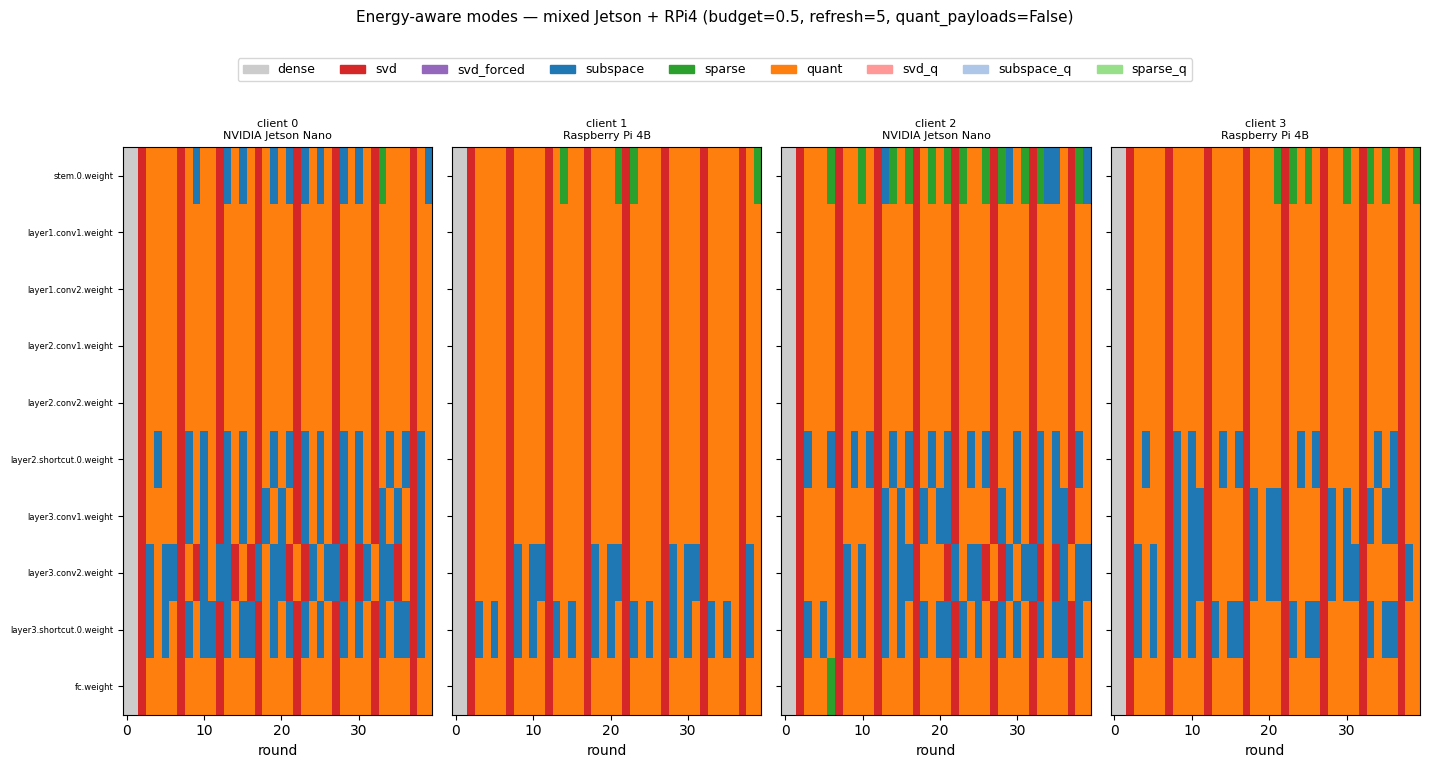

[mixed Jetson + RPi4] client 0 (NVIDIA Jetson Nano) — modes per round:
  round  0: {'dense': 56}
  round  4: {'quant': 9, 'dense': 46, 'subspace': 1}
  round  8: {'quant': 7, 'dense': 46, 'subspace': 3}
  round 12: {'svd': 9, 'dense': 46, 'subspace': 1}
  round 16: {'quant': 8, 'dense': 46, 'svd': 1, 'subspace': 1}
  round 20: {'quant': 8, 'dense': 46, 'subspace': 2}
  round 24: {'quant': 9, 'dense': 46, 'subspace': 1}
  round 28: {'subspace': 4, 'dense': 46, 'quant': 5, 'svd': 1}
  round 32: {'svd': 9, 'dense': 46, 'quant': 1}
  round 36: {'quant': 8, 'dense': 46, 'subspace': 2}


In [11]:
# (2) MIXED fleet: even clients = Jetson Nano (cheap compute -> svd/subspace),
# odd clients = Raspberry Pi 4 (compute matters -> quant). Same algorithm, same
# round — the per-client heatmaps differ PURELY because of hardware energy ratios.
JET = DEVICE_PROFILES["jetson_nano"]
RPI = DEVICE_PROFILES["raspberry_pi_4"]
_ = run_energy_aware(lambda c: JET if c % 2 == 0 else RPI,
                     label="mixed Jetson + RPi4", shown=(0,1,2,3),
                     refresh_period=5, budget=0.5)

## Composed candidates — structural mode ⊕ quant (`ea_quantize_payloads`)

Quantisation is an **orthogonal 2nd-stage codec**: every structural mode emits
*floats* we can quantise on top, adding `svd_q` / `subspace_q` / `sparse_q` to the
candidate set (`dense⊕quant` == plain `quant`, not duplicated). At 8-bit it ~quarters
the float payload for ~0.008 extra rel-error, so the quantised variant usually
dominates its raw counterpart on the energy/error Pareto front.

Below: Jetson Nano with `ea_quantize_payloads=True`. Expect `svd_q`/`subspace_q`
(light red / light blue) to replace the raw `svd`/`subspace`. The server decode
dequantises the payloads (`qfactors` flag), and the basis cached for `subspace_q` is
the **dequantised** `U` so client and server stay synchronised.

> On a Raspberry Pi 4 (`e_byte/e_flop≈200`) the composed modes barely change anything
> because plain `quant` already wins (compute is expensive) — composition mainly helps
> on compute-cheap devices, which is why it is OFF in the RPi4 config.

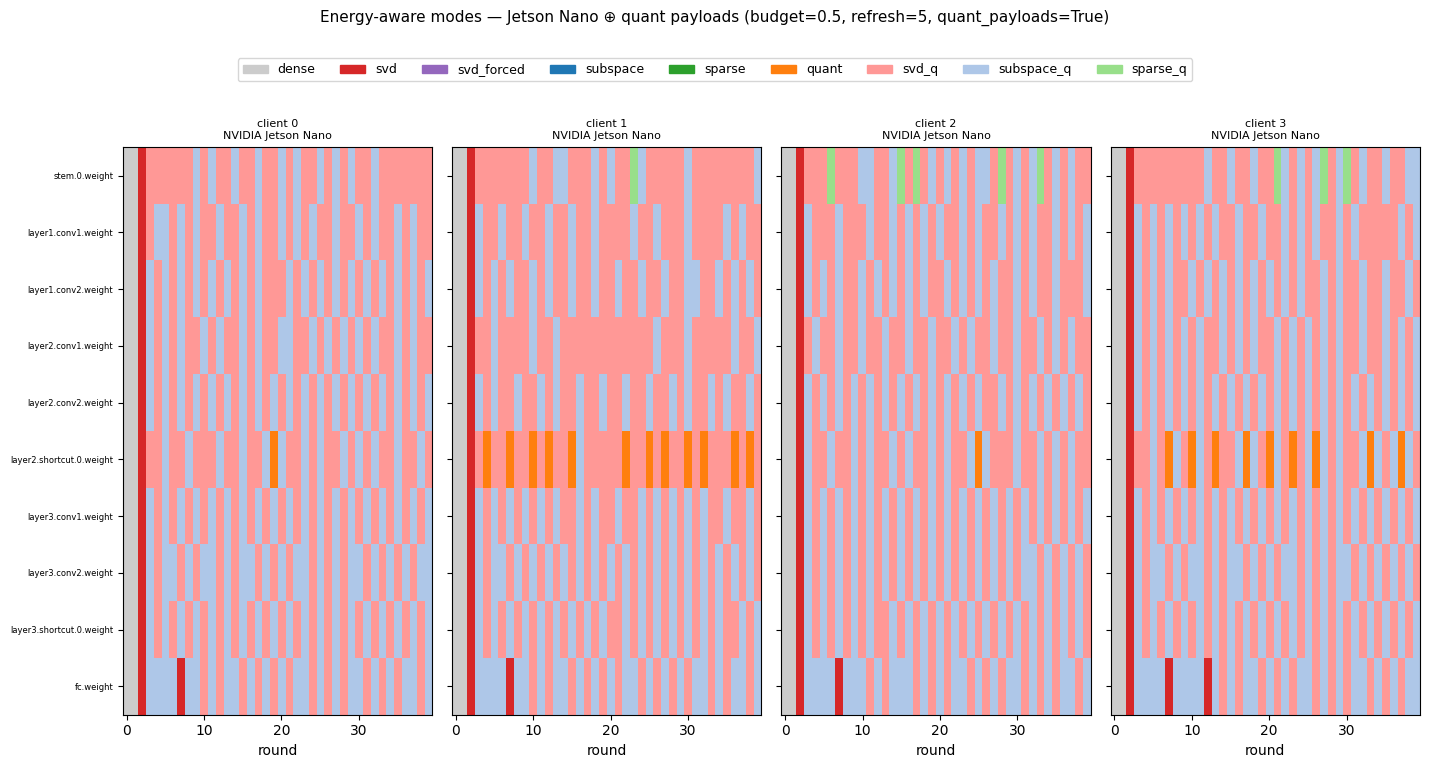

[Jetson Nano ⊕ quant payloads] client 0 (NVIDIA Jetson Nano) — modes per round:
  round  0: {'dense': 56}
  round  4: {'svd_q': 8, 'dense': 46, 'subspace_q': 2}
  round  8: {'svd_q': 7, 'dense': 46, 'subspace_q': 3}
  round 12: {'svd_q': 7, 'dense': 46, 'subspace_q': 3}
  round 16: {'svd_q': 8, 'dense': 46, 'subspace_q': 2}
  round 20: {'subspace_q': 6, 'dense': 46, 'svd_q': 4}
  round 24: {'svd_q': 8, 'dense': 46, 'subspace_q': 2}
  round 28: {'svd_q': 8, 'dense': 46, 'subspace_q': 2}
  round 32: {'subspace_q': 6, 'dense': 46, 'svd_q': 4}
  round 36: {'svd_q': 8, 'dense': 46, 'subspace_q': 2}


In [12]:
# Composition ON, Jetson Nano: the float payloads of svd/subspace get quantised.
JET = DEVICE_PROFILES["jetson_nano"]
rec_q = run_energy_aware(lambda c: JET, label="Jetson Nano ⊕ quant payloads",
                         refresh_period=5, budget=0.5,
                         quantize_payloads=True, payload_bits=8)